In [ ]:
Copyright Matlantis Corp. as contributors to Matlantis contrib project

# Test-area methodによる液体の表面張力の計算

## 計算モデル例    
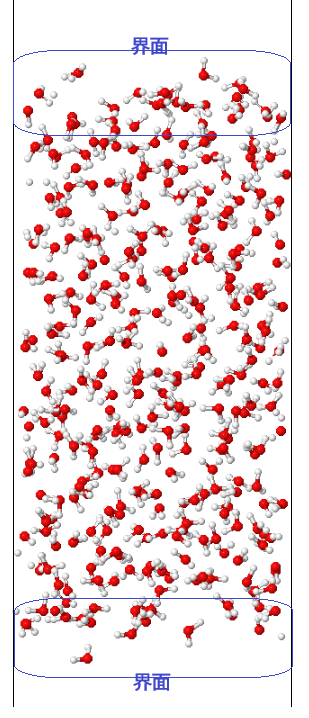


#### 界面を持つ系の瞬間的な全エネルギーを計算した後に、仮想的に界面の面積を微小変化させ、その際の自由エネルギー変化から表面張力を求めます。  
- 表面張力の計算式

$$\gamma = \lim_{\Delta A \to 0} \frac{-k_B T}{\Delta A} \ln \langle \exp (-\Delta U / k_B T) \rangle$$

$k_B$: ボルツマン定数,&ensp;&ensp;$T$: 絶対温度,&ensp;&ensp;$\Delta A$: 表面積の変化量  
$\Delta U$: 表面積を変化させた際の構成エネルギーの変化量
,&ensp;&ensp; $\langle \dots \rangle$: アンサンブル平均

#### 分子動力学法で計算する場合は、以下の式を利用します。

- 有限差分による表面張力の計算式
$$\gamma = \frac{-k_B T}{2 \Delta S} \left( \ln \langle \exp (-\Delta U^+ / k_B T) \rangle - \ln \langle \exp (-\Delta U^- / k_B T) \rangle \right)$$

$\Delta S$: 表面積の全変化量, &ensp;&ensp; $\Delta U^+$, $\Delta U^-$: 表面積を増加/減少させた際の構成エネルギーの変化量

#### 以下の例ではセル長の増減率を0.5%から0.01%まで段階的に変えて表面張力の計算を実行します。
#### 計算式上はセル長の増減率が小さい(つまりΔSが小さい)ほど精度が良くなりますが、小さすぎると数値誤差により精度が悪化します。
#### 各増減率で計算した表面張力から適切な値を選ぶ必要があります。
片側差分値であるPlus side と Minus sideの値と中心差分値を比較することで、精度が推定できます。  
例えば、以下の例では Scaling Ratioを0.05%から0.01%へと小さくしても片側差分値は中心差分値に近づいていて、数値誤差の影響は顕在化していません。  
この場合、表面張力の計算値が 86.5 mN/m あたりに収束していくことが予測されます。  


--- Scaling Ratio: 0.5000% ---  
 Surface Tension:  78.8635 mN/m  
 (Plus side :  299.8905 mN/m)  
 (Minus side:  -142.1634 mN/m)  
--- Scaling Ratio: 0.1000% ---  
 Surface Tension:  84.9232 mN/m  
 (Plus side :  79.3176 mN/m)  
 (Minus side:  90.5288 mN/m)  
--- Scaling Ratio: 0.0500% ---  
 Surface Tension:  86.0545 mN/m  
 (Plus side :  82.9504 mN/m)  
 (Minus side:  89.1586 mN/m)  
--- Scaling Ratio: 0.0100% ---  
 Surface Tension:  86.4717 mN/m  
 (Plus side :  85.4853 mN/m)  
 (Minus side:  87.4580 mN/m)  

## パラメータ設定
計算条件はすべて以下のセルで設定します。  
**どのセルを実行する場合も、最初にこのパラメータセルを実行してください**（カーネル再起動後も同様です）。

In [ ]:
from pfp_api_client.pfp.estimator import EstimatorCalcMode

# --- 共通設定 ---

# PFP の交換相関汎関数 (MD とエネルギー計算で共通)
calc_mode = EstimatorCalcMode.R2SCAN
# PFP モデルのバージョン (MD とエネルギー計算で共通)
model_version = "v8.0.0"
# 温度 (K; MD の熱浴温度と表面張力計算の逆温度 β に共通で使用)
temperature_K = 375.0
# トラジェクトリーファイル (MD の出力先 / エネルギー計算の入力)
traj_filename = "md.traj"
# 真空領域とみなす最小の厚さ (Å)
min_vacuum_thickness = 10.0

# --- MD 設定 ---

# 初期構造ファイル (xy 平面に界面を持ち、z 方向に真空領域を持つスラブモデル)
initial_structure_filename = "input/water.xyz"
# 時間ステップ (fs)
time_step = 1.00
# Langevin 熱浴の摩擦係数 (fs^-1)
friction_coeff = 0.0005
# 構造・ログの出力間隔 (ステップ数)
num_interval = 100
# MD の総ステップ数 (1 fs × 500000 = 500 ps)
num_md_steps = 500000
# MD ログの出力先
log_filename = "sampling.log"

# --- Test-area 法の設定 ---

# セル長 (x, y) の増減率 (キー: 計算ラベル, 値: 増減率)
scaling_ratios = {"A": 0.005, "B": 0.001, "C": 0.0005, "D": 0.0001}

# --- セル実行サマリー ---
print("=" * 70)
print("【このセルで実行した内容】")
print(" - 計算パラメータの定義 (共通 / MD / Test-area 法)")
print("【次のセルで実行する内容】")
print(f" - MD による構造サンプリング ({traj_filename} の生成)")
print(f"   ({traj_filename} が既にある場合は Test-area 法のセルへ進めます)")
print("=" * 70)

【このセルで実行した内容】
 - 計算パラメータの定義 (共通 / MD / Test-area 法)
【次のセルで実行する内容】
 - MD による構造サンプリング (md.traj の生成)
   (md.traj が既にある場合は Test-area 法のセルへ進めます)


## MDによる構造サンプリング例 (Langevin dynamicsによるNVT シミュレーション)
水の表面張力の計算に必要なトラジェクトリーファイルを生成するコード例です
water.xyzから初期構造を読み込み、500 psのNVTシミュレーションを行い、100 fsごとに構造をサンプリングします。

In [ ]:
# ※ 計算パラメータは先頭の「パラメータ設定」セルで指定してください

import os

import numpy as np
from ase import units
from ase.io import read
from ase.md import MDLogger
from ase.md.langevin import Langevin
from pfp_api_client.pfp.calculators.ase_calculator import ASECalculator
from pfp_api_client.pfp.estimator import Estimator

# トラジェクトリーファイルが既に存在する場合は MD をスキップする
md_skipped = os.path.exists(traj_filename)

if md_skipped:
    print(f"Skip: トラジェクトリーファイル ({traj_filename}) が既に存在するため、")
    print("      MD をスキップしました。MD を再実行する場合は、このファイルを")
    print("      削除するか、パラメータセルの traj_filename を変更してください。")
else:
    # PFP Estimator の設定 (パラメータセルの calc_mode / model_version を使用)
    estimator = Estimator(calc_mode=calc_mode, model_version=model_version)
    calculator = ASECalculator(estimator)

    # 初期構造の読み込み
    atoms = read(initial_structure_filename)
    atoms.calc = calculator

    # --- 初期構造のチェック ---
    # 表面張力計算には xy 平面に界面を持つスラブモデルが必要なため、
    # z 方向にのみ真空領域が存在することを確認する
    cell = atoms.get_cell()
    positions = atoms.get_positions()
    max_gaps = []
    for axis in range(3):
        length = cell[axis][axis]
        # 周期境界を考慮した、原子が存在しない領域の最大幅 (Å)
        coords = np.sort(positions[:, axis] % length)
        wrap_gap = coords[0] + (length - coords[-1])
        max_gaps.append(max(np.diff(coords).max(), wrap_gap))
    gap_x, gap_y, gap_z = max_gaps

    if gap_z < min_vacuum_thickness:
        raise ValueError(
            f"エラー: z 方向の真空領域が不足しています (最大空隙 {gap_z:.2f} Å)。\n"
            f"表面張力計算には z 方向に {min_vacuum_thickness} Å 以上の真空領域が必要です。"
        )
    if max(gap_x, gap_y) >= min_vacuum_thickness:
        raise ValueError(
            f"エラー: x/y 方向に真空領域が検出されました "
            f"(x: {gap_x:.2f} Å, y: {gap_y:.2f} Å)。\n"
            "界面が xy 平面と平行になるように構造を作成してください。"
        )
    print(f"Check: z 方向の真空領域を確認しました (厚さ 約 {gap_z:.2f} Å)")

    # 1.0 fs 時間ステップを利用するため、水素を重水素に置き換える
    # （構造サンプリングには影響しない）
    # 重水素の質量 (amu)
    deuterium_mass = 2.014
    target_indices = [
        index
        for index, symbol in enumerate(atoms.get_chemical_symbols())
        if symbol == "H"
    ]
    modified_masses = atoms.get_masses()
    for index in target_indices:
        modified_masses[index] = deuterium_mass
    atoms.set_masses(modified_masses)

    # Langevin ダイナミクスによる NVT-MD の設定
    dyn = Langevin(
        atoms,  # 対象の Atoms オブジェクト
        time_step * units.fs,  # 時間ステップ (ASE 内部単位に変換)
        friction=friction_coeff,  # 熱浴の摩擦係数
        temperature_K=temperature_K,  # 熱浴の温度 (K)
        loginterval=num_interval,  # トラジェクトリーの出力間隔 (ステップ数)
        trajectory=traj_filename,  # トラジェクトリーの出力先
    )

    # MD ログの出力設定
    dyn.attach(
        MDLogger(
            dyn,  # 対象の MD ダイナミクス
            atoms,  # 対象の Atoms オブジェクト
            log_filename,  # ログの出力先
            header=True,  # ヘッダー行を出力する
            stress=True,  # 応力を出力する
            peratom=True,  # エネルギーを原子あたりの値で出力する
            mode="w",  # 上書きモードで書き込む
        ),
        interval=num_interval,  # ログの出力間隔 (ステップ数)
    )

    # MD 実行
    dyn.run(num_md_steps)

# --- セル実行サマリー ---
print()
print("=" * 70)
print("【このセルで実行した内容】")
if md_skipped:
    print(f" - 既存の {traj_filename} を検出したため、MD をスキップ")
else:
    md_time_ps = num_md_steps * time_step / 1000.0
    sampling_interval_fs = num_interval * time_step
    print(
        f" - 初期構造 ({initial_structure_filename}) の読み込みと"
        " z 方向の真空層チェック"
    )
    print(
        f" - Langevin ダイナミクスによる {temperature_K} K,"
        f" {md_time_ps:.0f} ps の NVT-MD"
    )
    print(
        f" - {sampling_interval_fs:.0f} fs ごとの構造サンプリング"
        f" ({traj_filename} に保存)"
    )
    print(f" - MD ログの出力 ({log_filename})")
print("【次のセルで実行する内容】")
print(f" - {traj_filename} を読み込み、テストエリア法のエネルギー計算を実行")
print("   (セル直交性・真空層・Calculator 整合性のチェック後、基準セルと")
print("    変形セル (±側) のエネルギーを計算して npy/npz ファイルに保存)")
print("=" * 70)

Skip: トラジェクトリーファイル (md.traj) が既に存在するため、
      MD をスキップしました。MD を再実行する場合は、このファイルを
      削除するか、パラメータセルの traj_filename を変更してください。

【このセルで実行した内容】
 - 既存の md.traj を検出したため、MD をスキップ
【次のセルで実行する内容】
 - md.traj を読み込み、テストエリア法のエネルギー計算を実行
   (セル直交性・真空層・Calculator 整合性のチェック後、基準セルと
    変形セル (±側) のエネルギーを計算して npy/npz ファイルに保存)


## Test-area 法による表面張力計算コード

In [ ]:
# ※ 計算パラメータは先頭の「パラメータ設定」セルで指定してください
# ※ このセル以降のコードは、通常の利用では変更する必要はありません

import math
import os

import numpy as np
from ase.io import Trajectory
from pfp_api_client.pfp.calculators.ase_calculator import ASECalculator
from pfp_api_client.pfp.estimator import Estimator

# 表面張力計算に必要なエネルギーファイルの一式
energy_filenames = ["eng0.npy"]
for target in scaling_ratios:
    energy_filenames += [f"engp_{target}.npz", f"engm_{target}.npz"]

# ファイル一式がすべて存在する場合はエネルギー計算をスキップする
energy_calc_skipped = all(os.path.exists(name) for name in energy_filenames)

if energy_calc_skipped:
    print("Skip: 表面張力計算用のエネルギーファイル一式が既に存在するため、")
    print("      エネルギー計算をスキップしました。再計算する場合は以下の")
    print("      ファイルを削除してください:")
    print(f"      {', '.join(energy_filenames)}")
else:
    # MD で計算したトラジェクトリーの読み込み
    traj = Trajectory(traj_filename)

    # PFP Estimator の設定 (パラメータセルの calc_mode / model_version を使用)
    # MD 時と共通のパラメータを参照するため、設定の不一致は起こらない
    estimator = Estimator(calc_mode=calc_mode, model_version=model_version)
    calculator = ASECalculator(estimator)

    # 基準セルの取得 (NVT シミュレーションのため全フレームで共通)
    cell = traj[0].get_cell()

    # --- 計算前のチェック ---

    # 1. セル形状のチェック
    #    テストエリア法の実装が直交セルを前提としているため、
    #    セルの非対角成分がすべてゼロであることを確認する
    is_orthorhombic = True
    for i in range(3):
        for j in range(3):
            if i != j:
                # abs_tol: 非対角成分をゼロとみなす許容誤差 (Å)
                if not math.isclose(cell[i][j], 0.0, abs_tol=1e-9):
                    is_orthorhombic = False
    if not is_orthorhombic:
        raise ValueError(
            f"エラー: 入力されたセルが直交していません。\n{cell}\n"
            "テストエリア法の実装が直交セルを前提としているため、計算を中止します。"
        )
    print("Check: セルの直交性を確認しました。")

    # 2. 真空層のチェック
    #    テストエリア法は xy 平面に界面を持つスラブモデルを前提としているため、
    #    初期構造の z 方向にのみ真空領域が存在することを確認する
    positions = traj[0].get_positions()
    max_gaps = []
    for axis in range(3):
        length = cell[axis][axis]
        # 周期境界を考慮した、原子が存在しない領域の最大幅 (Å)
        coords = np.sort(positions[:, axis] % length)
        wrap_gap = coords[0] + (length - coords[-1])
        max_gaps.append(max(np.diff(coords).max(), wrap_gap))
    gap_x, gap_y, gap_z = max_gaps

    if gap_z < min_vacuum_thickness:
        raise ValueError(
            f"エラー: z 方向の真空領域が不足しています (最大空隙 {gap_z:.2f} Å)。\n"
            f"テストエリア法には z 方向に {min_vacuum_thickness} Å 以上の真空領域が必要です。"
        )
    if max(gap_x, gap_y) >= min_vacuum_thickness:
        raise ValueError(
            f"エラー: x/y 方向に真空領域が検出されました "
            f"(x: {gap_x:.2f} Å, y: {gap_y:.2f} Å)。\n"
            "界面が xy 平面と平行になるように構造を作成してください。"
        )
    print(f"Check: z 方向の真空領域を確認しました (厚さ 約 {gap_z:.2f} Å)")

    # 3. Calculator 整合性チェック (最初と最後のフレームのみ)
    #    トラジェクトリーに保存されたエネルギーと現在の Calculator による
    #    再計算値を比較し、MD 時と同じモデル設定であることを確認する

    # 許容するエネルギー差 (eV/atom)
    energy_tolerance_per_atom = 1e-6
    # チェックするフレームのインデックス (最初と最後)
    check_indices = [0, -1]

    for idx in check_indices:
        atoms_check = traj[idx]
        n_atoms = len(atoms_check)
        # トラジェクトリーに保存されたエネルギー (eV)
        stored_eng_0 = atoms_check.get_potential_energy()
        atoms_check.calc = calculator
        # 現在の Calculator による再計算値 (eV)
        recalculated_eng_0 = atoms_check.get_potential_energy()

        diff_per_atom = abs(stored_eng_0 - recalculated_eng_0) / n_atoms
        if diff_per_atom > energy_tolerance_per_atom:
            raise ValueError(
                f"整合性エラー: 差異 {diff_per_atom:.6f} eV/atom\n"
                "MD時のモデルと現在のCalculatorの設定が異なります。"
            )
        print(f"Consistency check passed: {diff_per_atom:.6e} eV/atom")

    # --- エネルギー計算 ---

    # 変形前 (基準セル) のエネルギーを全フレームで事前に計算し、保存する
    eng_0_list = [atoms.get_potential_energy() for atoms in traj]
    np.save("eng0.npy", eng_0_list)

    # 収束性確認のため、パラメータセルで指定した複数の増減率で計算を試行
    for target, ratio in scaling_ratios.items():
        # 基準セルの各辺の長さ (Å)
        lx = cell[0][0]
        ly = cell[1][1]
        lz = cell[2][2]

        # +側 (面積増加) のセル寸法:
        # x, y を増減率 ratio だけ伸ばし、体積が変わらないように z を縮める
        dlx = lx * ratio
        dly = ly * ratio
        lx_p = lx + dlx
        ly_p = ly + dly
        lz_p = lx * ly * lz / (lx_p * ly_p)

        # xy 断面積の変化量 ds (Å^2)
        # 変形前の断面積
        s0 = lx * ly
        # 変形後の断面積
        s = lx_p * ly_p
        ds = s - s0

        # -側 (面積減少) のセル寸法:
        # 断面積が s0 - ds となるように x, y を係数 f_m で縮め、
        # 体積が変わらないように z を伸ばす
        f_m = math.sqrt((s0 - ds) / s0)
        lx_m = lx * f_m
        ly_m = ly * f_m
        lz_m = (lx * ly * lz) / (lx_m * ly_m)

        # 変形後の直交セルを作成
        cell_p = cell.copy()
        cell_m = cell.copy()
        cell_p[0] = [lx_p, 0.0, 0.0]
        cell_p[1] = [0.0, ly_p, 0.0]
        cell_p[2] = [0.0, 0.0, lz_p]
        cell_m[0] = [lx_m, 0.0, 0.0]
        cell_m[1] = [0.0, ly_m, 0.0]
        cell_m[2] = [0.0, 0.0, lz_m]

        # 各フレームについて、変形後 (±側) のエネルギーを計算
        eng_p_list = []
        eng_m_list = []
        for atoms in traj:
            # scale_atoms=True: セルの変形に合わせて原子位置もスケールする
            atoms_p = atoms.copy()
            atoms_p.set_cell(cell_p, scale_atoms=True)
            atoms_m = atoms.copy()
            atoms_m.set_cell(cell_m, scale_atoms=True)
            atoms_p.calc = calculator
            atoms_m.calc = calculator
            eng_p_list.append(atoms_p.get_potential_energy())
            eng_m_list.append(atoms_m.get_potential_energy())

        # 計算結果の保存
        #   eng: 変形後のエネルギー列 (eV), ds: 断面積の変化量 (Å^2)
        np.savez(f"engp_{target}", eng=eng_p_list, ds=ds)
        np.savez(f"engm_{target}", eng=eng_m_list, ds=ds)

# --- セル実行サマリー ---
print()
print("=" * 70)
print("【このセルで実行した内容】")
if energy_calc_skipped:
    print(" - 既存のエネルギーファイル一式を検出したため、エネルギー計算をスキップ")
    print(f"   ({', '.join(energy_filenames)})")
else:
    print(f" - トラジェクトリー ({traj_filename}) の読み込みと計算前チェック")
    print("   (セル直交性・真空層・Calculator 整合性)")
    print(" - 変形前 (基準セル) のエネルギー計算 (eng0.npy に保存)")
    print(f" - {len(scaling_ratios)} 種類の増減率での変形セル (±側) のエネルギー計算")
    print("   (engp_*.npz / engm_*.npz に保存)")
print("【次のセルで実行する内容】")
print(" - 保存したエネルギーから各増減率の表面張力を計算して表示")
print("   (中心差分値 Surface Tension と片側差分値 Plus/Minus side)")
print("=" * 70)

Skip: 表面張力計算用のエネルギーファイル一式が既に存在するため、
      エネルギー計算をスキップしました。再計算する場合は以下の
      ファイルを削除してください:
      eng0.npy, engp_A.npz, engm_A.npz, engp_B.npz, engm_B.npz, engp_C.npz, engm_C.npz, engp_D.npz, engm_D.npz

【このセルで実行した内容】
 - 既存のエネルギーファイル一式を検出したため、エネルギー計算をスキップ
   (eng0.npy, engp_A.npz, engm_A.npz, engp_B.npz, engm_B.npz, engp_C.npz, engm_C.npz, engp_D.npz, engm_D.npz)
【次のセルで実行する内容】
 - 保存したエネルギーから各増減率の表面張力を計算して表示
   (中心差分値 Surface Tension と片側差分値 Plus/Minus side)


In [ ]:
# ※ 計算パラメータは先頭の「パラメータ設定」セルで指定してください

import numpy as np

# --- 物理定数と単位変換係数 ---
# ボルツマン定数 (J/K)
kB_jK = 1.380649e-23
# ボルツマン定数 (eV/K)
kB_eVK = kB_jK / 1.602176e-19
# 逆温度 β = 1/(kB T) (eV^-1)
beta = 1.0 / (temperature_K * kB_eVK)
# 単位変換係数: eV/Å^2 → mN/m
conv_factor = 1e20 * 1.602176634e-19 * 1000.0

# 変形前 (基準セル) のエネルギー列 (eV; 全ターゲット共通)
eng_0_list = np.load("eng0.npy")

for target in scaling_ratios:
    # +側 (面積増加) の計算結果を読み込み
    data = np.load(f"engp_{target}.npz")
    # 変形後のエネルギー列 (eV)
    eng_p_list = data["eng"]
    # 断面積の変化量 (Å^2)
    ds_p = data["ds"]

    # -側 (面積減少) の計算結果を読み込み
    data = np.load(f"engm_{target}.npz")
    eng_m_list = data["eng"]
    ds_m = data["ds"]

    if ds_p != ds_m:
        raise ValueError("面積変化(dS) がプラス側とマイナス側で一致しません。")

    # スラブモデルでは上下２つの界面があるので、界面の面積変化は 2*dS
    dS = ds_p * 2

    # エネルギー差分 ΔU+ / ΔU- (eV)
    dup = eng_p_list - eng_0_list
    dum = eng_m_list - eng_0_list

    # アンサンブル平均 ln⟨exp(-βΔU)⟩
    ln_exp_p = np.log(np.mean(np.exp(-beta * dup)))
    ln_exp_m = np.log(np.mean(np.exp(-beta * dum)))

    # 片側差分による表面張力 (eV/Å^2) とその中心差分値
    surface_tension_eV_ang_p = -1.0 / (beta * dS) * ln_exp_p
    surface_tension_eV_ang_m = 1.0 / (beta * dS) * ln_exp_m
    surface_tension_eV_ang = (surface_tension_eV_ang_p + surface_tension_eV_ang_m) / 2.0

    # mN/m へ換算
    surface_tension = surface_tension_eV_ang * conv_factor
    surface_tension_p = surface_tension_eV_ang_p * conv_factor
    surface_tension_m = surface_tension_eV_ang_m * conv_factor

    # セル長の増減率 (%)
    scaling_percent = scaling_ratios[target] * 100
    print(f"--- Scaling Ratio: {scaling_percent:.4f}% ---")
    print(f" Surface Tension:  {surface_tension:.4f} mN/m")
    print(f" (Plus side :  {surface_tension_p:.4f} mN/m)")
    print(f" (Minus side:  {surface_tension_m:.4f} mN/m)")

# --- セル実行サマリー ---
print()
print("=" * 70)
print("【このセルで実行した内容】")
print(" - 保存したエネルギーから各増減率の表面張力を計算して表示")
print("   (中心差分値 Surface Tension と片側差分値 Plus/Minus side)")
print("【次のセルで実行する内容】")
print(" - なし (これで計算は完了です)")
print(" - 増減率を小さくした際に片側差分値が中心差分値に近づいているかを")
print("   確認し、収束していれば中心差分値を表面張力として採用してください")
print("=" * 70)

--- Scaling Ratio: 0.5000% ---
 Surface Tension:  78.8635 mN/m
 (Plus side :  299.8905 mN/m)
 (Minus side:  -142.1634 mN/m)
--- Scaling Ratio: 0.1000% ---
 Surface Tension:  84.9232 mN/m
 (Plus side :  79.3176 mN/m)
 (Minus side:  90.5288 mN/m)
--- Scaling Ratio: 0.0500% ---
 Surface Tension:  86.0545 mN/m
 (Plus side :  82.9504 mN/m)
 (Minus side:  89.1586 mN/m)
--- Scaling Ratio: 0.0100% ---
 Surface Tension:  86.4717 mN/m
 (Plus side :  85.4853 mN/m)
 (Minus side:  87.4580 mN/m)

【このセルで実行した内容】
 - 保存したエネルギーから各増減率の表面張力を計算して表示
   (中心差分値 Surface Tension と片側差分値 Plus/Minus side)
【次のセルで実行する内容】
 - なし (これで計算は完了です)
 - 増減率を小さくした際に片側差分値が中心差分値に近づいているかを
   確認し、収束していれば中心差分値を表面張力として採用してください
